# Programming with Python for Health Research

**Structure of 7th session - visualisation**

1. Basic plot
    * Plot styles
2. Bar charts
3. Histogram
4. Scatter plots
5. Boxplots
6. Subplots
7. Representation of data

# 1. Basic plot
* Below is the code to create a basic line plot discussed as discussed in the lecture

In [1]:
# import packages
import pandas as pd
import numpy as np

# Import the pyplot object from matplotlib
from matplotlib import pyplot as plt

import plotly.express as px
import seaborn as sns

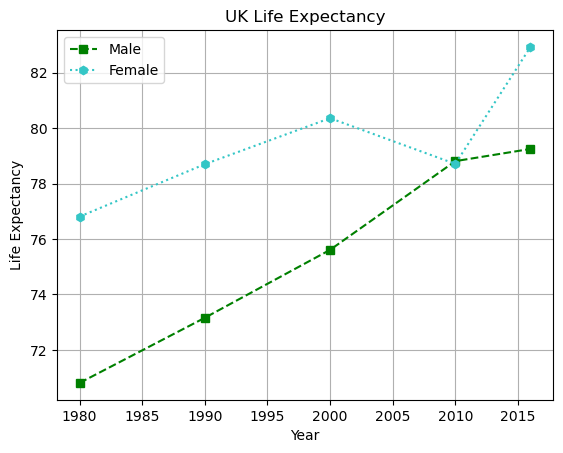

In [2]:
# basic plot using matplotlib
years = [1980, 1990, 2000, 2010, 2016]
life_exp_men = [70.81, 73.16, 75.61, 78.81, 79.25]
life_exp_women = [76.81, 78.7, 80.36, 78.71, 82.93]

df = pd.DataFrame({'Year': years, 
                   'Male': life_exp_men, 
                   'Female': life_exp_women})

# Create the plot
plt.plot(df['Year'], df['Male'], 'sg--', label='Male')
plt.plot(df['Year'], df['Female'], color='#34C6C6', linestyle=":", marker="h",label='Female')

# Add labels and title
plt.xlabel('Year')
plt.ylabel('Life Expectancy')
plt.title('UK Life Expectancy')

plt.legend()
plt.grid(True)
plt.show()

Plotly creates an interactive plot. If you zoom in and want to return to the original view, double click on the graph. If a group of data (e.g. a line) has disappeared, check that the group of data is selected in the interactive legend.

In [2]:
# basic plot using plotly
years = [1980, 1990, 2000, 2010, 2016]
life_exp_men = [70.81, 73.16, 75.61, 78.81, 79.25]
life_exp_women = [76.81, 78.7, 80.36, 78.71, 82.93]

df = pd.DataFrame({'Year': years, 
                   'Male': life_exp_men, 
                   'Female': life_exp_women})

fig = px.line(df, x='Year', y=['Male', 'Female'], title='UK life expectancy')
fig.update_layout(yaxis_title="Life Expectancy")

fig.show()


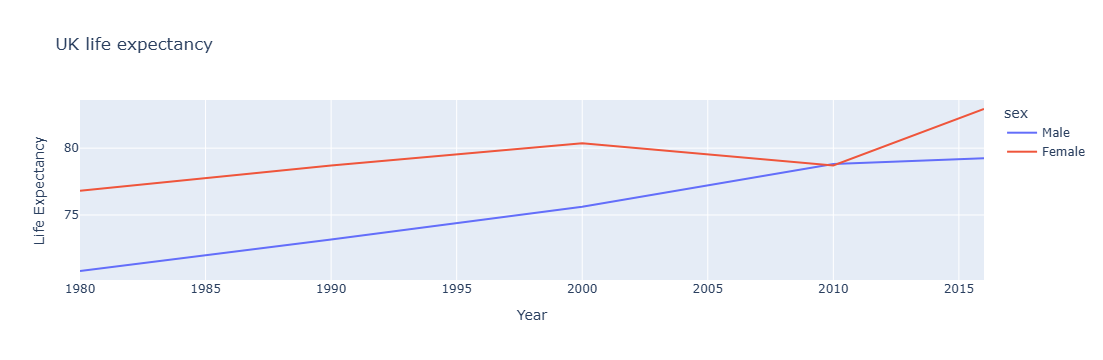

In [4]:
# basic plot using plotly and long data format

long_df = pd.melt(df, id_vars='Year', value_vars=['Male', 'Female'], var_name='sex', value_name='life_exp')

fig = px.line(long_df, x='Year', y='life_exp', color = 'sex', title='UK life expectancy')
fig.update_layout(yaxis_title="Life Expectancy")

fig.show()


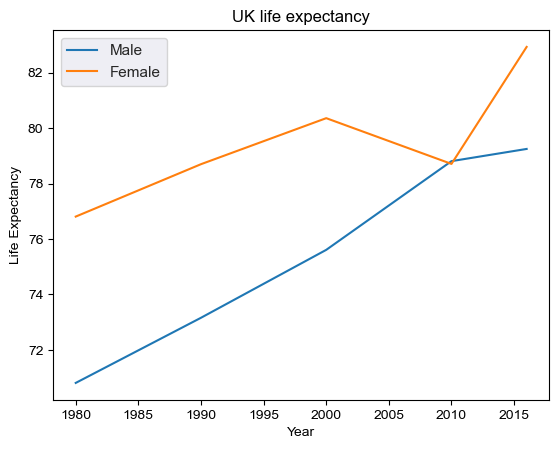

In [5]:
# basic plot using seaborn
years = [1980, 1990, 2000, 2010, 2016]
life_exp_men = [70.81, 73.16, 75.61, 78.81, 79.25]
life_exp_women = [76.81, 78.7, 80.36, 78.71, 82.93]

df = pd.DataFrame({'Year': years, 
                   'Male': life_exp_men, 
                   'Female': life_exp_women})

sns.lineplot(data=df, x='Year', y='Male', label='Male')
sns.lineplot(data=df, x='Year', y='Female', label='Female')

sns.set_theme()

plt.title('UK life expectancy')
plt.xlabel('Year')
plt.ylabel('Life Expectancy')

plt.legend()
plt.show()

#### _Exercise 1_
* Create a nicely formatted line plot of the following data using matplotlib.

| Country        | 1990 | 1995 | 2000 | 2005 | 2010 | 2015 | 
|----------------|------|------|------|------|------|------| 
| Burundi        | 16.4 | 15.9 | 13.4 | 10.7 | 9.16 | 9.01 | 
| Kenya          | 6.79 | 6.74 | 6.35 | 5.83 | 5.4  | 5.06 | 
| United Kingdom | 1.3  | 1.15 | 1.03 | 0.88 | 0.73 | 0.63 | 
| Singapore      | 0.75 | 0.47 | 0.37 | 0.39 | 0.3  | 0.23 | 

* The datasets includes rows from the [gapminder](https://www.gapminder.org/data/) dataset describing observed burn deaths (per 100 000 people) per country.
  * Description from gapminder: _Burns, age-adjusted mortality per 100 000 standard population. This rate is calculated as if all countries had the same age composition of the population. [source link](https://www.who.int/gho/en/)_
* In this exercise, try to make the same plot using one other package (either plotly or seaborn).

In [7]:
df = pd.read_csv("data/burns_deaths_per_100000_people.csv")
countries = ['Burundi', 'Kenya', 'United Kingdom', 'Singapore']
years = ['1990', '1995', '2000', '2005', '2010', '2015']


## 1.2 Plot style
* Matplotlib comes packaged with a range of different plotting styles. To see these run the command `print(plt.style.available)`

#### _Exercise 2_
* Explore different plot styles by adding the command `plt.style.use('name_of_style')` as the first line of the plot you generated in exercise 1.

To return to defult style run the below code

In [11]:
import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)

For the remainder of this exercise, you may choose any plotting package to complete the exercises.

# 2. Bar charts
* Bar charts are used to display and compare measures such as number or frequency for different discrete categories of data.
* Bar charts are made by specifying the ```.bar``` method.
    * The width of the bar can be controled with the ```width``` argument and we can also set the ```edgecolor```
* We can create a side-by-side bar chart by defining a pandas datafram and setting the index equal to the category we want to group by in this case country.

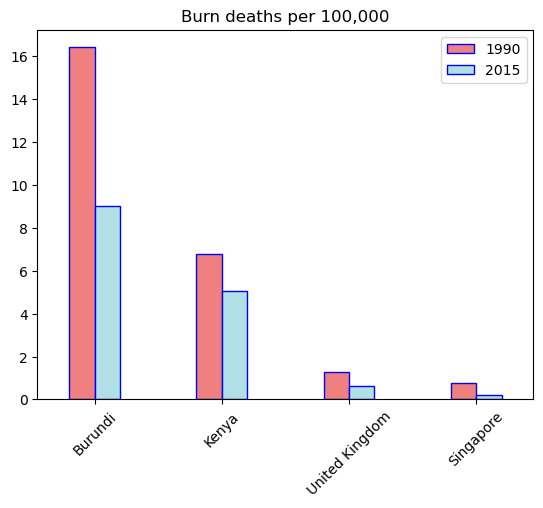

In [12]:
country = ['Burundi', 'Kenya', 'United Kingdom', 'Singapore']
burn_deaths_1990 = [16.4, 6.79, 1.3, 0.75]
burn_deaths_2015 = [9.01, 5.06, 0.63, 0.23]

# Convert to dataframe
df = pd.DataFrame({'country': country, '1990': burn_deaths_1990, '2015': burn_deaths_2015})

# Create plot
my_colors = ["#F08080", "#B0E0E6"]
df.plot.bar(rot = 45, color = my_colors, edgecolor = 'blue', width = 0.4) # rot = degree to which x-labels should be rotated

# Add title and country as x labels
plt.title('Burn deaths per 100,000') # We can add extra features such as title before plt.show()
plt.xticks(ticks=df.index, labels = df['country']) #  with xticks we can specify what labels that we want to use 
plt.show()

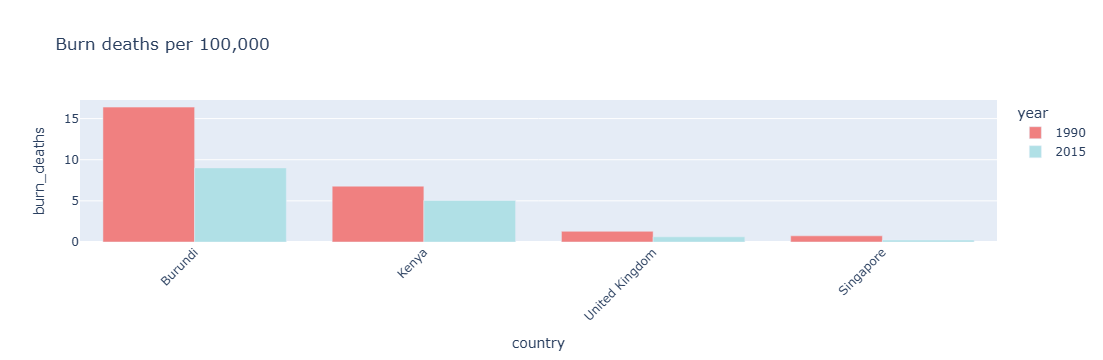

In [13]:
country = ['Burundi', 'Kenya', 'United Kingdom', 'Singapore']
burn_deaths_1990 = [16.4, 6.79, 1.3, 0.75]
burn_deaths_2015 = [9.01, 5.06, 0.63, 0.23]

# Convert to dataframe
df = pd.DataFrame({'country': country, '1990': burn_deaths_1990, '2015': burn_deaths_2015})
# Convert to long format
long_df = pd.melt(df, id_vars='country', value_vars=['1990', '2015'], var_name='year', value_name='burn_deaths')

# Create plot
my_colors = ["#F08080", "#B0E0E6"]
fig = px.bar(long_df, x="country", y="burn_deaths", color="year", barmode="group", color_discrete_sequence=my_colors, title='Burn deaths per 100,000')
fig.update_layout(xaxis_tickangle=-45)

fig.show()


## Plot sizes
You can change the size of the plots produced by changing the following parameters 
- `plt.figure(figsize = (15,10))` before a plt plot

or

- `df.plot(figsize= (15,10))` for a dataframe plot

or if you want to change the dafult figure sizes for the whole jupyter notebook.

- `plt.rcParams['figure.figsize'] = [10, 5]`

#### _Exercise 3_
* Load in the full burns dataset using pandas `pd.read.csv` from the file `data/burns_deaths_per_100000_people.csv`
* Subset the data to only include data from the years 1996, 2006 & 2016
* Then create a grouped bar chart as above.

#### _Exercise 4_
* Create a horizontal barplot for the data in exercise 3

_Hint_: You may find these functions to be helpful `plt.barh` and `px.bar(..., orientation='h')`

#### _Exercise 5_
* Bars and lines can be mixed in one plot
* Modify the vertical bar chart from above by:
    1. Calculating the mean across the three years
    2. Reorder the data by the mean value
    3. In addition to the bars include a line showing the mean for each country.   

#### _Exercise 6_
* Save the above figure. For matplotlib, add the code `plt.savefig('my_filname.png')` right before `plt.show()`. For plotly, use `fig.write_image('my_filname.png')`
* Check in your folder (where this notebook is located) that the plot file has been generated correctly.


# 3. Histograms
* Histograms are great for assessing the distribution of a variable
* The `bins` argument is used to define the number of bars the data is divided into
* Below is an example of a histogram plotting a skewed distribution

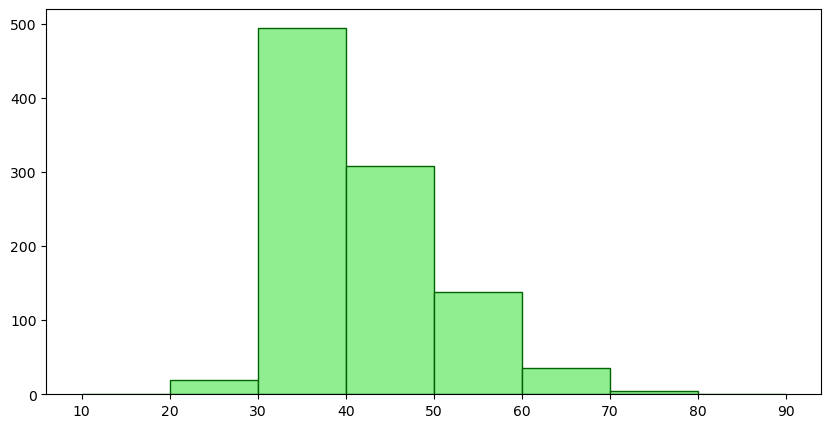

In [20]:
# SciPy is a library that builds on numpy to give more mathematical functions
# Here we use it to create random ages following a skewed normal distribution with the skewnorm.rvs function
from scipy.stats import skewnorm
np.random.seed(42)
ages = skewnorm.rvs(a=20, loc=30, scale=15, size=1000) # a = skewness factor, loc = mean, scale = standard deviation
plt.hist(ages, color='lightgreen', edgecolor='darkgreen', bins=[10, 20, 30, 40, 50, 60, 70, 80, 90])
plt.show()



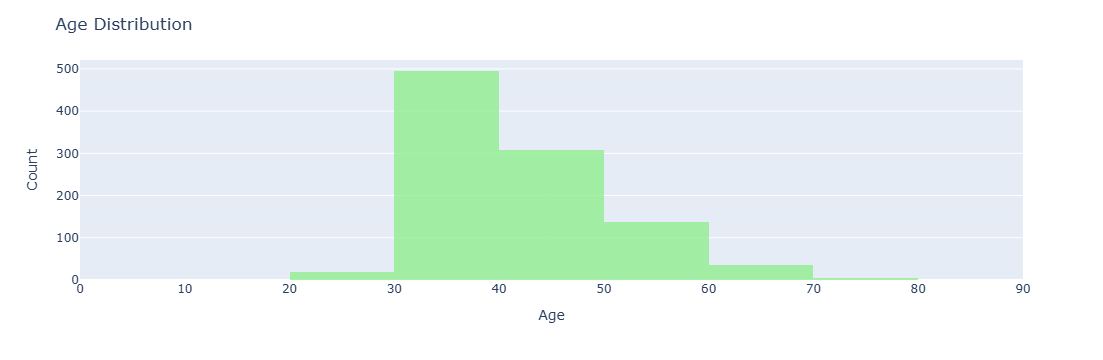

In [21]:
# SciPy is a library that builds on numpy to give more mathematical functions
# Here we use it to create random ages following a skewed normal distribution with the skewnorm.rvs function
from scipy.stats import skewnorm

np.random.seed(42)
ages = skewnorm.rvs(a=20, loc=30, scale=15, size=1000) # a = skewness factor, loc = mean, scale = standard deviation

fig = px.histogram(x=ages, nbins=10, color_discrete_sequence=['lightgreen'], opacity=0.8)
fig.update_layout(title='Age Distribution', xaxis_title='Age', yaxis_title='Count')
fig.update_xaxes(range=[0, 90])
fig.show()


#### _Exercise 7_
* Adapt the histogram code example given above:
    * Change the value given to the bins argument; instead of a list pass a single integer defining the number of bars.
        * Indicate how many bins should be used with a single integer.
    * Add a vertical line (use `plt.axvline()` or `fig.add_vrect`) that intercept the x-axis at the mean.
    * Explore what the argument `density = True` (matplotlib) or `histnorm ='probability density'` (plotly) does to the y-axis of the histogram
    * Change the range of data to include in the plot with the argument `range = (min, max)` (matplotlib)
    * (matplotlib) Finally load the seaborn plotting library `import seaborn as sns` and use its kernel density estimation plot to add a density line
        * 1. use `ax = plt.gca()` to get current axes. See documentation [here](https://matplotlib.org/3.1.1/api/_as_gen/matplotlib.pyplot.gca.html).
        * 2. add the line `sns.kdeplot(ages, ax=ax)` to add a density line to the histogram, see documentation [here](https://seaborn.pydata.org/generated/seaborn.kdeplot.html).
    * (plotly) Finally use the `marginal="violin"` argument to add a violin plot to the histogram, see documentation [here](https://plotly.com/python/distplot/).


# 4. Scatterplot
* With a scatter plot we have multiple dimensions to show different aspects of our data.
    * x, y, color, size, and marker are the most commonly used
* Below is a code example of how this can be done

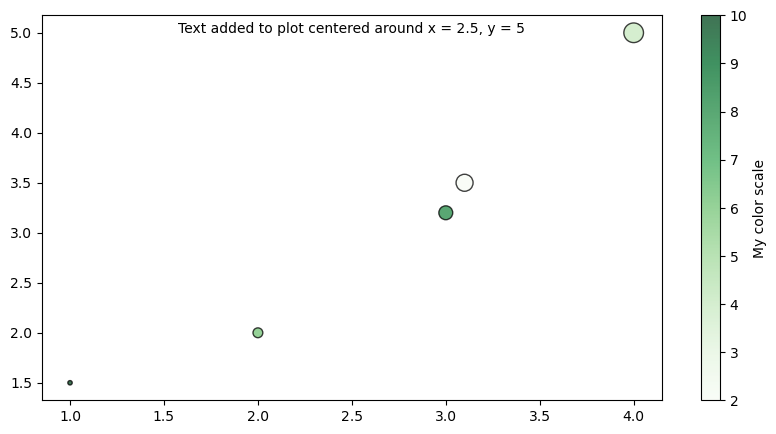

In [24]:
x = [1, 2, 3, 3.1, 4]
y = [1.5, 2, 3.2, 3.5, 5]
mycolors = [10, 6, 8, 2, 4]
mysizes = [10, 50, 100, 150, 200]
plt.scatter(x, y, s = mysizes, c = mycolors, cmap = 'Greens', 
            edgecolor = 'black', linewidth = 1, alpha = 0.75) # alpha sets a transparency factor for the color
cbar =  plt.colorbar()
cbar.set_label("My color scale")
plt.text(2.5, 5,'Text added to plot centered around x = 2.5, y = 5', fontsize=10, ha='center')
plt.show()


In [25]:
x = [1, 2, 3, 3.1, 4]
y = [1.5, 2, 3.2, 3.5, 5]
mycolors = [10, 6, 8, 2, 4]
mysizes = [10, 50, 100, 150, 200]

fig = px.scatter(
    x=x,
    y=y,
    size=mysizes,
    color=mycolors,
    color_continuous_scale='Greens',
    opacity=0.75,
    labels={'color': 'My color scale'}
)
fig.add_annotation(text= 'Text added to plot centered around x = 2.5, y = 5', x= 2.5, y= 5)
fig.update_traces(marker=dict(line=dict(color='black', width=1)))

fig.show()


#### _Exercise 8_
* Looking again at the patient numbers for registered practices `data/gp-reg-patients-prac-quin-age.csv`
* Generate a new variable summing up all patients older than 90
* Use this along with other existing or newly generated variables to create a scatter plot which uses all four dimensions
    * x, y, size and color

## 6.1 Box plots
* Box plots provide a good way to show difference in distribution between groups or categories
* Example code below

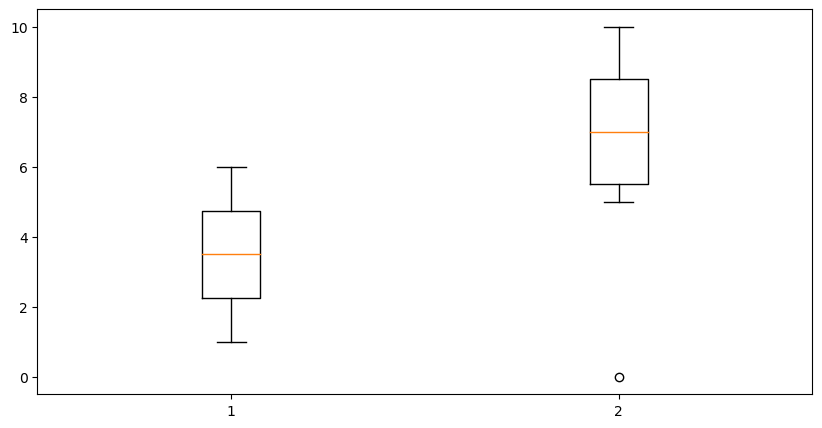

In [27]:
x = [1, 2, 3, 4, 5, 6]
y = [0, 5, 6, 7, 8, 9, 10]
plt.boxplot([x, y])
plt.show()

In [28]:
x = [1, 2, 3, 4, 5, 6]
y = [0, 5, 6, 7, 8, 9, 10]

plot_df1 = pd.DataFrame({'xy': 'x', 'value': x})
plot_df2 = pd.DataFrame({'xy': 'y', 'value': y})
plot_df = pd.concat([plot_df1, plot_df2])

fig = px.box(plot_df, x='xy', y='value')
fig.show()

#### _Exercise  9_
* In the data of registered practices the column called `NHSE_COMM_REGION_CODE` describes the NHS-England Commissioning Region that every practice belong to. [Details on the codes can be found here](https://geoportal.statistics.gov.uk/datasets/1b1c3439570e428880aaabf37d6fa378/explore)
* Generate a box plot showing the difference in `Total_All` patients between the commissioning regions.

#### _Exercise 10_
* Improve the boxplot by:
    * Use proper labels for the groups from the [linked description](https://geoportal.statistics.gov.uk/datasets/1b1c3439570e428880aaabf37d6fa378/explore).
        * A description of how labels can be set can be found from [stackexchange here](https://stats.stackexchange.com/questions/3476/how-to-name-the-ticks-in-a-python-matplotlib-boxplot), hint scroll to the answer.
    * Add a title
    * Add arguments `notch='True'` and/or `vert = 0`

* Seaborn also have various methods to perform boxplots, example below.
* Is this plot better or worse?

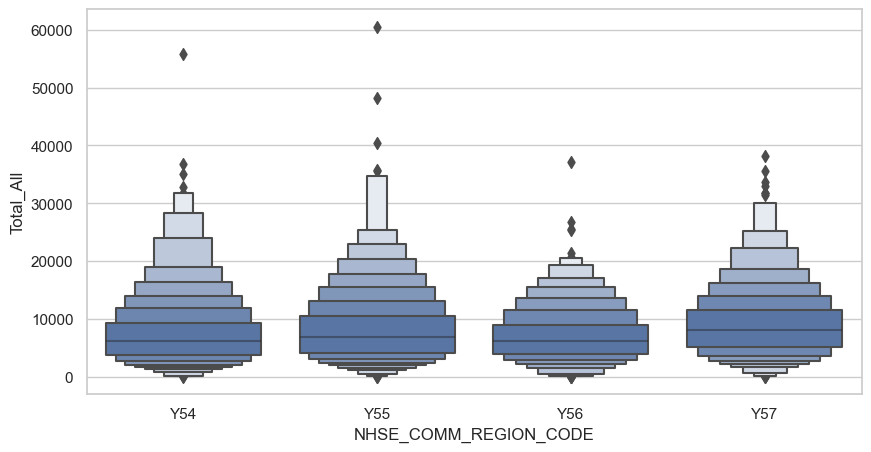

In [33]:
# Example of a fancy boxplot using seaborn
import seaborn as sns
sns.set(style="whitegrid")
sns.boxenplot(x="NHSE_COMM_REGION_CODE", y="Total_All", color="b", scale="linear", data=df)
plt.show()

#### _Exercise 11_
* Two more data files can be found in the data folder for this session
    * `gapminder_alcohol_consumption.csv`
    * `gapminder_population_characteristics.csv`
* All data is from [Gapminder](https://www.gapminder.org/data/) including only European countries. Measures are from 2008 except _Age at 1st marriage women_ which is from 2005
* Load in the data with pandas and merge the two datasets by country.
* Get an overview of the correlations in the data by running the seaborn pairsplot: `sns.pairplot(df)`

#### _Exercise 12_
* Based on the correlation matrix create a plot of your choice that showcase one or more correlation(s) in the data

# 7. Subplots 
* Useful for generating plots with shared axis within the same figure
* Example below

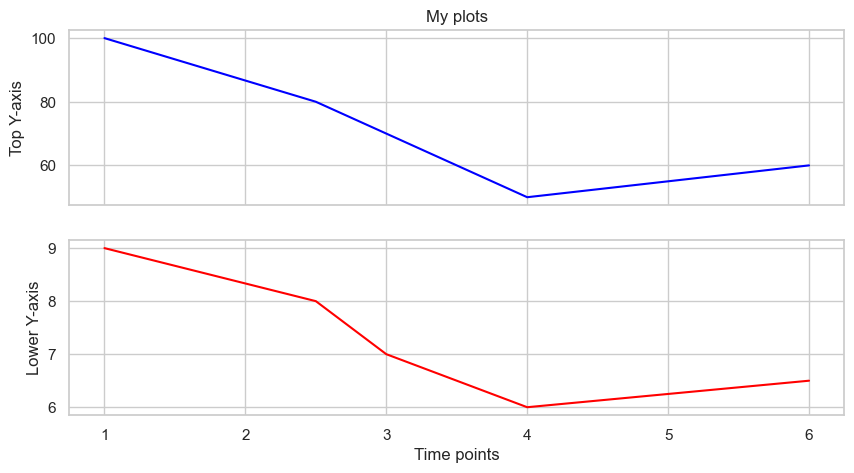

In [36]:
x = [1, 2.5, 3, 4, 6]
y1 = [100, 80, 70, 50, 60]
y2 = [9, 8, 7, 6, 6.5]

fig, (ax1, ax2) = plt.subplots(nrows = 2, ncols = 1, sharex = True)
ax1.plot(x, y1, color = "blue")
ax2.plot(x, y2, color = "red")

ax1.set_title("My plots")
ax1.set_ylabel("Top Y-axis")
ax2.set_ylabel("Lower Y-axis")
ax2.set_xlabel("Time points")

plt.show()


#### _Exercise 13_
* Create a subplot using a shared x-axis as above plotting variables from the Gapminder data

#### _Exercise 14_
* The file we used in the last session to lookup patient numbers for the _The Densham Surgery_ (gp_practice_code = A81001) is also available in the data folder for this session
    * You will find it here: `data/gp-reg-patients-prac-quin-age.csv`
* Select columns starting with "Female" and "Male"
* Using a subplot with shared y axis, displaying gender balance across different age groups with bars stemming from the middle vertical of the graph (i.e. x=0) also known as pyrimid plot

# 7. Representation of data
Tufte's concept of data-ink ratio is a measure of how minimalistic is the graphic representation of the data. By removing excess use of pixels or ink on the graph, we can remove clutter that would otherwise obscure the readability of the graph and distract from the main message. 

Tufte's lie factor is a measure of the accuracy of representing data in the graph. Ideally, a 10% change in the data is represented by a 10% visual change in the graph or visualisation.

Appropriate labels, titles, annotations, and captions all help to build context and help the reader to understand the graph. Most of the time, graphs are viewed as an independent piece of content, adding some text e.g. source of data, date, location would help to orientate the reader.

#### _Exercise 15_
* Recreate the following plot (in any plotting package of your choice)
* Reduce the data-ink ratio by removing unnecessary elements

![](population_age_marriage_scatterplot.png)